# Classga asoslangan projectni qurishni boshlaymiz

In [132]:
import pandas as pd

In [154]:
# read the dataset through calling read_csv() from pandas
df = pd.read_csv('kidney_dataset.csv')

In [104]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Target                    21000 non-null  str    
 1   Age                       21000 non-null  int64  
 2   Gender                    21000 non-null  int64  
 3   BMI                       21000 non-null  int64  
 4   Systolic_BP               21000 non-null  int64  
 5   Diastolic_BP              21000 non-null  int64  
 6   Heart_Rate                21000 non-null  int64  
 7   Serum_Creatinine          21000 non-null  int64  
 8   Blood_Urea_Nitrogen       21000 non-null  int64  
 9   eGFR                      21000 non-null  int64  
 10  Urine_Albumin             21000 non-null  int64  
 11  Urine_Protein             21000 non-null  int64  
 12  Albumin_Creatinine_Ratio  21000 non-null  int64  
 13  Urine_Specific_Gravity    21000 non-null  float64
 14  Sodium           

In [105]:
df.columns

Index(['Target', 'Age', 'Gender', 'BMI', 'Systolic_BP', 'Diastolic_BP',
       'Heart_Rate', 'Serum_Creatinine', 'Blood_Urea_Nitrogen', 'eGFR',
       'Urine_Albumin', 'Urine_Protein', 'Albumin_Creatinine_Ratio',
       'Urine_Specific_Gravity', 'Sodium', 'Potassium', 'Calcium',
       'Phosphorus', 'Chloride', 'Bicarbonate', 'Hemoglobin', 'RBC_Count',
       'WBC_Count', 'Platelet_Count', 'Packed_Cell_Volume',
       'Blood_Glucose_Random', 'Fasting_Glucose', 'HbA1c', 'Cholesterol',
       'Triglycerides', 'Serum_Albumin', 'Total_Protein', 'Diabetes',
       'Hypertension', 'Smoking_Status', 'Family_History_Kidney'],
      dtype='str')

In [106]:
# from sklearn.cluster import KMeans
# features = df[['Target', 'Age', 'Gender', 'BMI', 'Systolic_BP', 'Diastolic_BP',
#        'Heart_Rate', 'Serum_Creatinine', 'Blood_Urea_Nitrogen', 'eGFR',
#        'Urine_Albumin', 'Urine_Protein', 'Albumin_Creatinine_Ratio',
#        'Urine_Specific_Gravity', 'Sodium', 'Potassium', 'Calcium',
#        'Phosphorus', 'Chloride', 'Bicarbonate', 'Hemoglobin', 'RBC_Count',
#        'WBC_Count', 'Platelet_Count', 'Packed_Cell_Volume',
#        'Blood_Glucose_Random', 'Fasting_Glucose', 'HbA1c', 'Cholesterol',
#        'Triglycerides', 'Serum_Albumin', 'Total_Protein', 'Diabetes',
#        'Hypertension', 'Smoking_Status', 'Family_History_Kidney']]
# features = features.dropna()

# kmeans = KMeans(n_clusters=3)
# df['Target'] = kmeans.fit_predict(features)

In [107]:
df.isnull().sum()

Target                      0
Age                         0
Gender                      0
BMI                         0
Systolic_BP                 0
Diastolic_BP                0
Heart_Rate                  0
Serum_Creatinine            0
Blood_Urea_Nitrogen         0
eGFR                        0
Urine_Albumin               0
Urine_Protein               0
Albumin_Creatinine_Ratio    0
Urine_Specific_Gravity      0
Sodium                      0
Potassium                   0
Calcium                     0
Phosphorus                  0
Chloride                    0
Bicarbonate                 0
Hemoglobin                  0
RBC_Count                   0
WBC_Count                   0
Platelet_Count              0
Packed_Cell_Volume          0
Blood_Glucose_Random        0
Fasting_Glucose             0
HbA1c                       0
Cholesterol                 0
Triglycerides               0
Serum_Albumin               0
Total_Protein               0
Diabetes                    0
Hypertensi

In [155]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

class DataPreprocessing: 
    def __init__(self, df):
        self.df = df
    def miss_vals(self):
        for col in self.df.columns:
            if self.df[col].isnull().any():
                if self.df[col].dtype == 'str':
                    self.df[col].fillna(self.df[col].mode()[0], inplace=True)
                else:
                    self.df[col].fillna(self.df[col].mean(), inplace=True)
        return self

    def encodla(self):
        for col in self.df.select_dtypes(include=['str']).columns:
            # if self.df[col].nunique() <= 5:
            #     # get_dummies ishlatganda drop_first=True qilish tavsiya etiladi (Multicollinearity uchun)
            #     dummies = pd.get_dummies(self.df[col], prefix=col, dtype=int)
            #     self.df = pd.concat([self.df.drop(columns=col), dummies], axis=1)
            # else:
                le = LabelEncoder()
                self.df[col] = le.fit_transform(self.df[col])
        return self

    def scaling(self, target_column='Target'):
        scaler = MinMaxScaler()
        # Raqamli ustunlarni aniqlaymiz
        num_cols = self.df.select_dtypes(include=['int64', 'float64']).columns.tolist()
        # raqamli ustunlarda target_column bo'lsa, uni olib tashlaymiz
        if target_column in num_cols:
            num_cols.remove(target_column)
    
        if num_cols:
            self.df[num_cols] = scaler.fit_transform(self.df[num_cols])
        
        return self
dp = DataPreprocessing(df)
df_final = dp.miss_vals().encodla().scaling(target_column='Target').df

In [109]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Target                    21000 non-null  int64  
 1   Age                       21000 non-null  float64
 2   Gender                    21000 non-null  float64
 3   BMI                       21000 non-null  float64
 4   Systolic_BP               21000 non-null  float64
 5   Diastolic_BP              21000 non-null  float64
 6   Heart_Rate                21000 non-null  float64
 7   Serum_Creatinine          21000 non-null  float64
 8   Blood_Urea_Nitrogen       21000 non-null  float64
 9   eGFR                      21000 non-null  float64
 10  Urine_Albumin             21000 non-null  float64
 11  Urine_Protein             21000 non-null  float64
 12  Albumin_Creatinine_Ratio  21000 non-null  float64
 13  Urine_Specific_Gravity    21000 non-null  float64
 14  Sodium           

In [156]:
x = df_final.drop('Target', axis=1)
y = df_final['Target']

In [157]:
# train_test_split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [158]:
# Model Selection 
from sklearn.linear_model import LogisticRegression

In [159]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [160]:
y_lr_pred = lr.predict(x_test)

In [161]:
# Evaluation ----> Classification uchun
from sklearn.metrics import classification_report


In [162]:
cls_report = classification_report(y_test, y_lr_pred)
print(cls_report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3160
           1       1.00      1.00      1.00        93
           2       1.00      1.00      1.00       488
           3       1.00      1.00      1.00       305
           4       1.00      1.00      1.00       154

    accuracy                           1.00      4200
   macro avg       1.00      1.00      1.00      4200
weighted avg       1.00      1.00      1.00      4200



In [120]:
# Random Forest Classifiaction 
from sklearn.ensemble import RandomForestClassifier

rf_cls = RandomForestClassifier()
rf_cls.fit(x_train, y_train)
y_rf_pred = rf_cls.predict(x_test)

In [121]:
# Evaluation ----> Classification uchun
from sklearn.metrics import classification_report
rf_report = classification_report(y_test, y_rf_pred)
print(rf_report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3160
           1       1.00      1.00      1.00        93
           2       1.00      1.00      1.00       488
           3       1.00      1.00      1.00       305
           4       1.00      1.00      1.00       154

    accuracy                           1.00      4200
   macro avg       1.00      1.00      1.00      4200
weighted avg       1.00      1.00      1.00      4200



In [126]:
# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

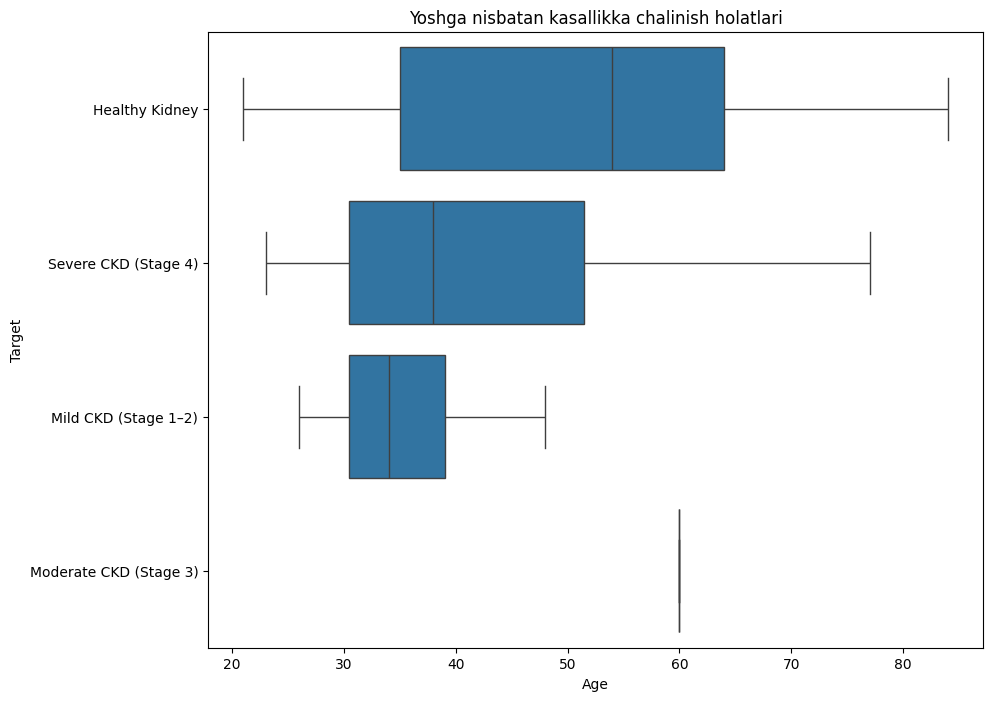

In [138]:
plt.figure(figsize=(10,8))

sns.boxplot(
    x='Age',
    y='Target',
    data=df.head(50)
)

plt.title('Yoshga nisbatan kasallikka chalinish holatlari')

plt.show()

In [137]:
# Yosh o'tkan sari buyrak kasallikka chalinish oshib borishligi aniqlandi

In [140]:
# Tabulate
from tabulate import tabulate


In [143]:
results = [
    ['Logistic Regression', 1.00, 1.00, 1.00],
    ['Random Forest Classifier', 1.00, 1.00, 1.00]
]
headers = ['Model', 'Accuracy', 'Recall', 'F1-score']
table = tabulate(results, headers=headers, tablefmt='grid', floatfmt='.2f')
print(table)

+--------------------------+------------+----------+------------+
| Module                   |   Accuracy |   Recall |   F1-score |
+==========================+============+==========+============+
| Logistic Regression      |       1.00 |     1.00 |       1.00 |
+--------------------------+------------+----------+------------+
| Random Forest Classifier |       1.00 |     1.00 |       1.00 |
+--------------------------+------------+----------+------------+


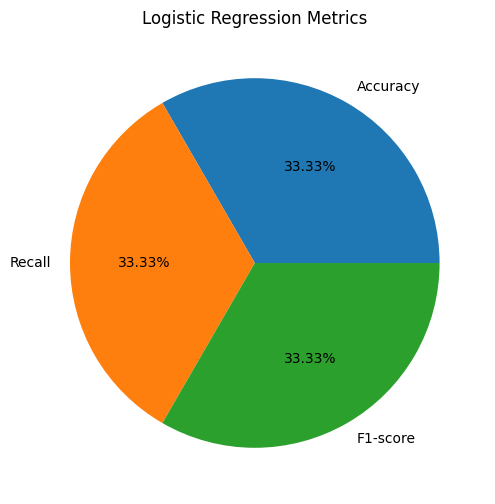

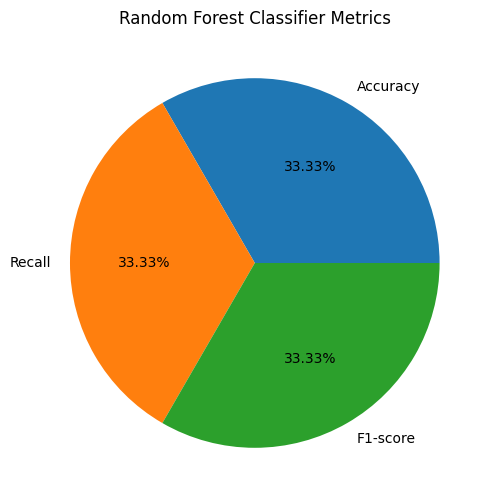

In [151]:
''' Har ikki model ham eng yaxshi natijalarni berdi. Bu balkim overfitting bo'lishi mumkin. '''

import matplotlib.pyplot as plt

labels = ['Accuracy', 'Recall', 'F1-score']
values = [1.00, 1.00, 1.00]

colors = ['green', 'yellow', 'yellow']

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.2f%%')
plt.title('Logistic Regression Metrics')
plt.show()

labels = ['Accuracy', 'Recall', 'F1-score']
values = [1.00, 1.00, 1.00]

colors = ['green', 'yellow', 'yellow']

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.2f%%')
plt.title('Random Forest Classifier Metrics')
plt.show()

In [165]:
# KFold validation 

from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(lr, x,y, cv=kf, scoring='accuracy')
print(scores)


[1. 1. 1. 1. 1.]


In [166]:
df_final.head()

,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,0,0.140625,1.0,0.6250,0.070707,0.152542,0.795918,0.000000,0.035211,0.789474,...,0.440678,0.591263,0.418605,0.100503,1.000000,0.697180,1.0,1.0,1.0,1.0
1,4,0.359375,0.0,0.0000,0.757576,0.677966,0.142857,0.555556,0.563380,0.201754,...,0.305085,0.547834,0.124031,0.889447,0.333333,0.958526,1.0,1.0,1.0,0.0
2,0,0.890625,0.0,0.8750,0.262626,0.050847,0.836735,0.000000,0.063380,0.833333,...,0.203390,0.852468,0.744186,1.000000,1.000000,0.694613,0.0,0.0,1.0,0.0
3,0,0.984375,0.0,0.3750,0.030303,0.254237,0.551020,0.000000,0.021127,0.842105,...,0.203390,0.547686,0.178295,0.929648,1.000000,0.476317,1.0,0.0,0.0,1.0
4,0,0.281250,1.0,0.0625,0.212121,0.169492,0.653061,0.000000,0.021127,0.850877,...,0.610169,0.729388,0.899225,0.974874,1.000000,0.951101,1.0,0.0,1.0,0.0


In [169]:
df_final.columns

Index(['Target', 'Age', 'Gender', 'BMI', 'Systolic_BP', 'Diastolic_BP',
       'Heart_Rate', 'Serum_Creatinine', 'Blood_Urea_Nitrogen', 'eGFR',
       'Urine_Albumin', 'Urine_Protein', 'Albumin_Creatinine_Ratio',
       'Urine_Specific_Gravity', 'Sodium', 'Potassium', 'Calcium',
       'Phosphorus', 'Chloride', 'Bicarbonate', 'Hemoglobin', 'RBC_Count',
       'WBC_Count', 'Platelet_Count', 'Packed_Cell_Volume',
       'Blood_Glucose_Random', 'Fasting_Glucose', 'HbA1c', 'Cholesterol',
       'Triglycerides', 'Serum_Albumin', 'Total_Protein', 'Diabetes',
       'Hypertension', 'Smoking_Status', 'Family_History_Kidney'],
      dtype='str')

In [170]:
from joblib import dump, load

In [171]:
dump(lr, 'kidney_disease.joblib')

['kidney_disease.joblib']